## RNN: Thorcino ways

The aim of this notebook is to show how to train a classic RNN using this framework


In [101]:
import numpy as np

N = 1000
T = 5

def create_sequence(len: int, start: float, stop: float) -> np.ndarray:
    return np.linspace(start, stop, len)

def create_random_sequences(n: int, len:int, min_start: int=10, seed: float=777) -> np.ndarray:
    rng = np.random.default_rng(seed)
    sequences = []
    for _ in range(n):
        start = rng.integers(1, min_start, size=1)[0]
        stop = start * 3
        seq = create_sequence(len+1, start, stop)

        sequences.append(seq)

    return np.stack(sequences)

Train = create_random_sequences(N, T, min_start=30)
Train = Train.reshape(Train.shape[0], Train.shape[1], 1)
Test = create_random_sequences(N, T, min_start=45)
Test = Test.reshape(Train.shape[0], Train.shape[1], 1)

X_tr, Y_tr = Train[:, :-1], Train[:, 1:]
X_te, Y_te = Test[:, :-1], Test[:, 1:]

In [102]:
"""Model architecture"""

from thorcino.activations import Identity, ReLU
from thorcino.layers import Sequential, RNN
from thorcino.losses import MSELoss
from thorcino.optimizer import SGD
from thorcino.training.schedulers import CosineSchedule
from thorcino.training.trainer import Trainer 

EPOCHS = 50
IN_FEATURE = 1
OUT_FEATURE = 1
HIDDEN_UNITS = 2
MAX_LR, MIN_LR = 1e-5, 1e-8

model = Sequential(
    RNN(
        IN_FEATURE, 
        OUT_FEATURE, 
        HIDDEN_UNITS, 
        h_activation=Identity(), 
        o_activation=Identity()
    ),
)
model.save_graph("./images/arch.png", True)
model.save_graph("./images/forward.png", False, True)
model.save_graph("./images/backward.png", False, backward=True)

loss = MSELoss()
optimizer = SGD(model.parameters, MAX_LR, 0.7)
scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer = Trainer(model, loss, optimizer, scheduler, 1e5)

In [103]:
"""Preprocessing"""

from thorcino.dataset import DataLoader, TensorDataset
from thorcino.tensor import Tensor

BATCH_SIZE = 16

X_tr, Y_tr = Tensor(X_tr), Tensor(Y_tr)
dataset_tr = TensorDataset(X_tr, Y_tr)
loader_tr = DataLoader(dataset_tr, BATCH_SIZE)

X_te, Y_te = Tensor(X_te), Tensor(Y_te)
dataset_te = TensorDataset(X_te, Y_te)
loader_te = DataLoader(dataset_te, BATCH_SIZE)

In [104]:
"""Training"""

EVAL_STEP = int(EPOCHS / 10)

train_losses, eval_losses = [], []
for e in range(EPOCHS):
    loss = trainer.train_epoch(loader_tr)
    train_losses.append(loss)

    if e%EVAL_STEP == 0:
        loss, _ = trainer.eval(loader_te)
        eval_losses.append(loss)

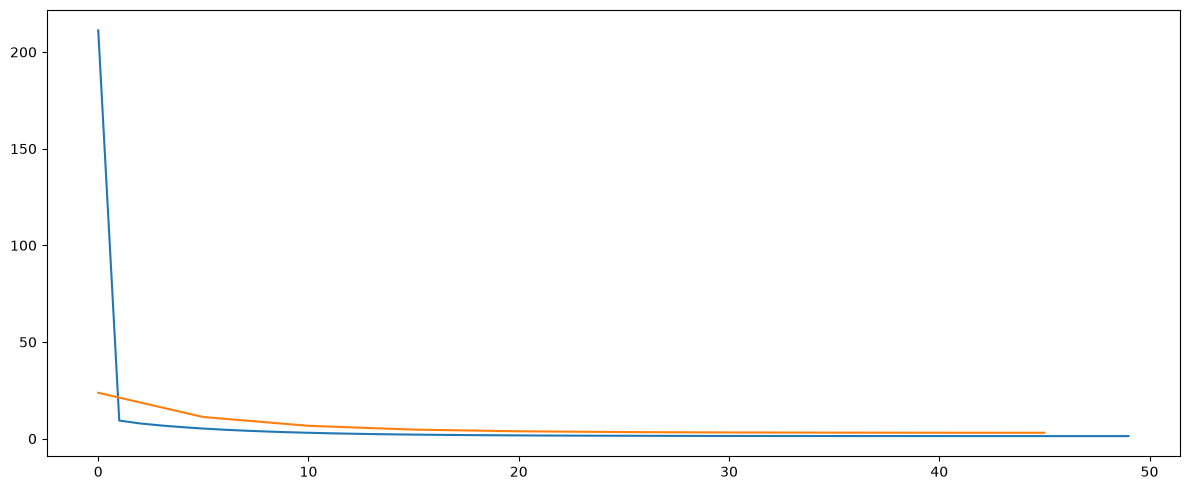

In [105]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(12, 5))

axs.plot(range(EPOCHS), train_losses)
axs.plot(range(0, EPOCHS, EVAL_STEP), eval_losses)

fig.tight_layout()
plt.show()

In [106]:
"""Inference time"""

from tabulate import tabulate

input, expected = X_te[4, :], Y_te[4, :]

model.eval()
preds = model(input).data.flatten()
expected = expected.data.flatten()

rows = []
for t, (exp, pred) in enumerate(zip(expected, preds)):
    diff = pred - exp
    pct_err = abs(diff) / abs(exp) * 100 if exp != 0 else float('nan')
    rows.append([t, f'{exp:.4f}', f'{pred:.4f}', f'{diff:+.4f}', f'{pct_err:.2f}%'])

print('-----------------------Test Values----------------------')
print(tabulate(
    rows,
    headers=['t', 'expected', 'predicted', 'diff', '% error'],
    tablefmt='rounded_outline',
    colalign=('center', 'right', 'right', 'right', 'right'),
))

-----------------------Test Values----------------------
╭─────┬────────────┬─────────────┬─────────┬───────────╮
│  t  │   expected │   predicted │    diff │   % error │
├─────┼────────────┼─────────────┼─────────┼───────────┤
│  0  │          7 │      6.8251 │ -0.1749 │     2.50% │
│  1  │          9 │      9.5057 │  0.5057 │     5.62% │
│  2  │         11 │     12.1864 │  1.1864 │    10.79% │
│  3  │         13 │      14.867 │   1.867 │    14.36% │
│  4  │         15 │     17.5476 │  2.5476 │    16.98% │
╰─────┴────────────┴─────────────┴─────────┴───────────╯


In [107]:
input, expected = X_tr[2, :], Y_tr[2, :]

model.eval()
preds = model(input).data.flatten()
expected = expected.data.flatten()

rows = []
for t, (exp, pred) in enumerate(zip(expected, preds)):
    diff = pred - exp
    pct_err = abs(diff) / abs(exp) * 100 if exp != 0 else float('nan')
    rows.append([t, f'{exp:.4f}', f'{pred:.4f}', f'{diff:+.4f}', f'{pct_err:.2f}%'])

print('-----------------------Train Values----------------------')
print(tabulate(
    rows,
    headers=['t', 'expected', 'predicted', 'diff', '% error'],
    tablefmt='rounded_outline',
    colalign=('center', 'right', 'right', 'right', 'right'),
))

-----------------------Train Values----------------------
╭─────┬────────────┬─────────────┬────────┬───────────╮
│  t  │   expected │   predicted │   diff │   % error │
├─────┼────────────┼─────────────┼────────┼───────────┤
│  0  │       15.4 │      14.867 │ -0.533 │     3.46% │
│  1  │       19.8 │     20.7643 │ 0.9643 │     4.87% │
│  2  │       24.2 │     26.6617 │ 2.4617 │    10.17% │
│  3  │       28.6 │      32.559 │  3.959 │    13.84% │
│  4  │         33 │     38.4564 │ 5.4564 │    16.53% │
╰─────┴────────────┴─────────────┴────────┴───────────╯
